In [2]:
import duckdb
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## Global Variables

In [3]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarsisUrbino12electric": "Urbino 12", "SolarsisUrbino18electric": "Urbino 18"}

## Helper Function

In [5]:
def _styled_boxplot(data, labels, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 7))

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        flierprops={"marker": "o", "markerfacecolor": "none", "markeredgecolor": "black", "markersize": 6},
        boxprops={"edgecolor": "black"},
    )

    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.85", linewidth=0.8)
    ax.xaxis.grid(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="both", colors="black")

    fig.tight_layout()
    return fig, ax

## Functions

In [13]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT
        scenario,
        seed,
        SUM(battery_totalEnergyConsumed) AS energy_consumed,
        SUM(battery_totalEnergyRegenerated) AS energy_regenerated
    FROM multirun_tripinfo
    GROUP BY scenario, seed
""").fetchdf()

con.close()

for scenario in ["summer", "winter", "reduced", "increased"]:
    scenario_df = df[df["scenario"] == scenario]
    print(scenario)


    scenario_df["energy_consumed"] = (
        scenario_df["energy_consumed"] - scenario_df["energy_regenerated"]
    ) / 1_000_000

    print(scenario_df.describe().to_string())

summer
            seed  energy_consumed  energy_regenerated
count   5.000000         5.000000        5.000000e+00
mean   69.000000       139.246598        1.793464e+08
std     3.807887         7.122829        9.803897e+06
min    65.000000       132.359910        1.701257e+08
25%    67.000000       134.269112        1.723078e+08
50%    68.000000       135.726166        1.743809e+08
75%    70.000000       146.924805        1.899220e+08
max    75.000000       146.952999        1.899955e+08
winter
            seed  energy_consumed  energy_regenerated
count   5.000000         5.000000        5.000000e+00
mean   69.000000       156.407956        1.758477e+08
std     3.807887         6.117506        9.634414e+06
min    65.000000       149.925882        1.667846e+08
25%    67.000000       152.592491        1.689333e+08
50%    68.000000       153.634426        1.709675e+08
75%    70.000000       162.915649        1.862409e+08
max    75.000000       162.971334        1.863122e+08
reduced
      

In [22]:
def plot_energy_consumption_boxplots():
    con = duckdb.connect("../../database/eBuS.duckdb")
    data = [df[df["scenario"] == scenario]["battery_totalEnergyConsumed"] for scenario in scenarios]
    for tripinfo_vType in df["tripinfo_vType"].unique():
        trip_data = [df[(df["scenario"] == scenario) & (df["tripinfo_vType"] == tripinfo_vType)]["battery_totalEnergyConsumed"] for scenario in scenarios]
        styled_boxplot(
            trip_data, scenarios, xlabel="Scenario", ylabel="Energy consumption [MWh]"
        )
        plt.show()

def styled_boxplot(data, labels, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 7))

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        flierprops={"marker": "o", "markerfacecolor": "none", "markeredgecolor": "black", "markersize": 6},
        boxprops={"edgecolor": "black"},
    )

    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.85", linewidth=0.8)
    ax.xaxis.grid(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="both", colors="black")

    fig.tight_layout()
    return fig, ax

plot_energy_consumption_boxplots()

KeyError: 'tripinfo_vType'

### Energy Consumption by Type over Time

   timestep_time  vehicle_actualBatteryCapacity vehicle_id  \
0            0.0                      419.30719   bus_1004   
1            0.0                      419.30719   bus_1004   
2            0.0                      419.30719   bus_1004   
3            0.0                      419.30719   bus_1004   
4            0.0                      419.30719   bus_1004   

         tripinfo_vType   scenario  seed  
0  Ebusco2.2electric12m  increased    65  
1  Ebusco2.2electric12m  increased    65  
2  Ebusco2.2electric12m  increased    65  
3  Ebusco2.2electric12m  increased    65  
4  Ebusco2.2electric12m    reduced    65  
summer


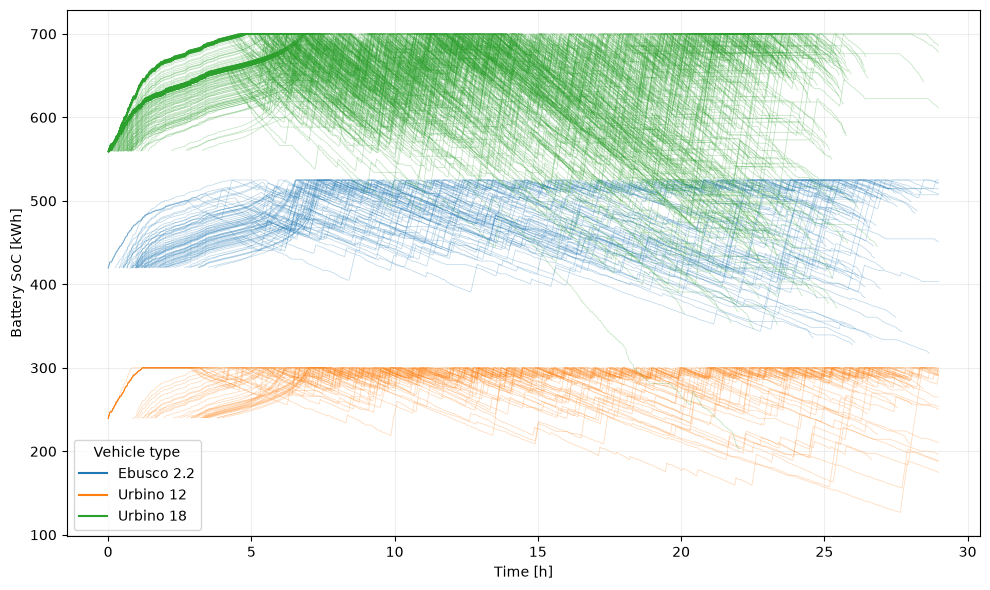

winter


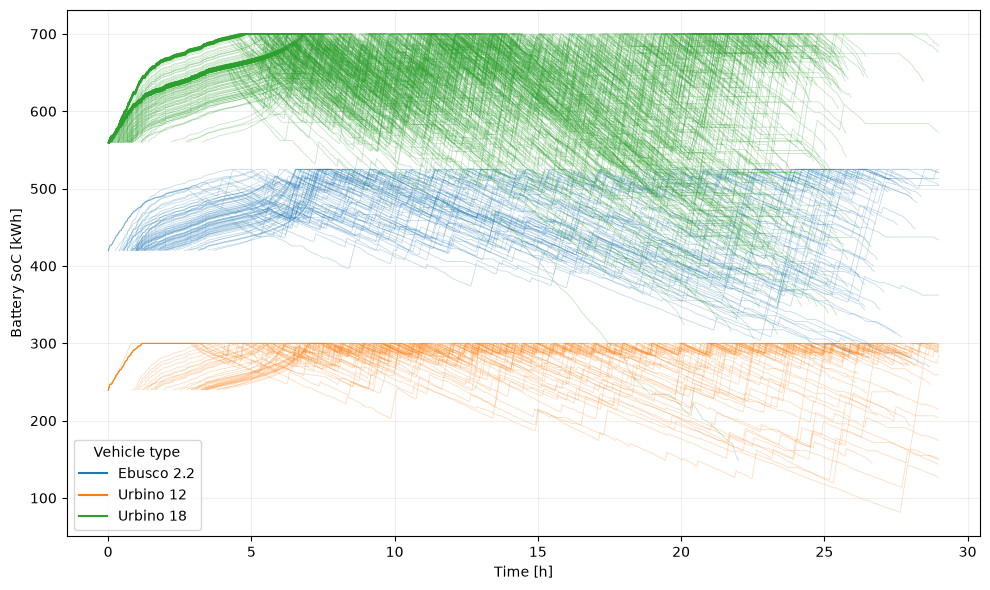

reduced


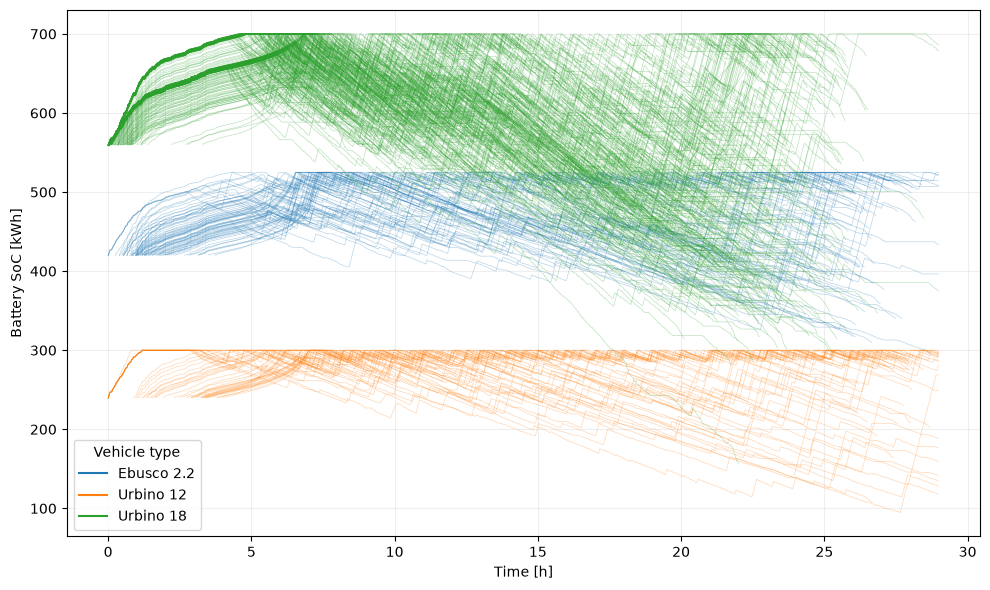

increased


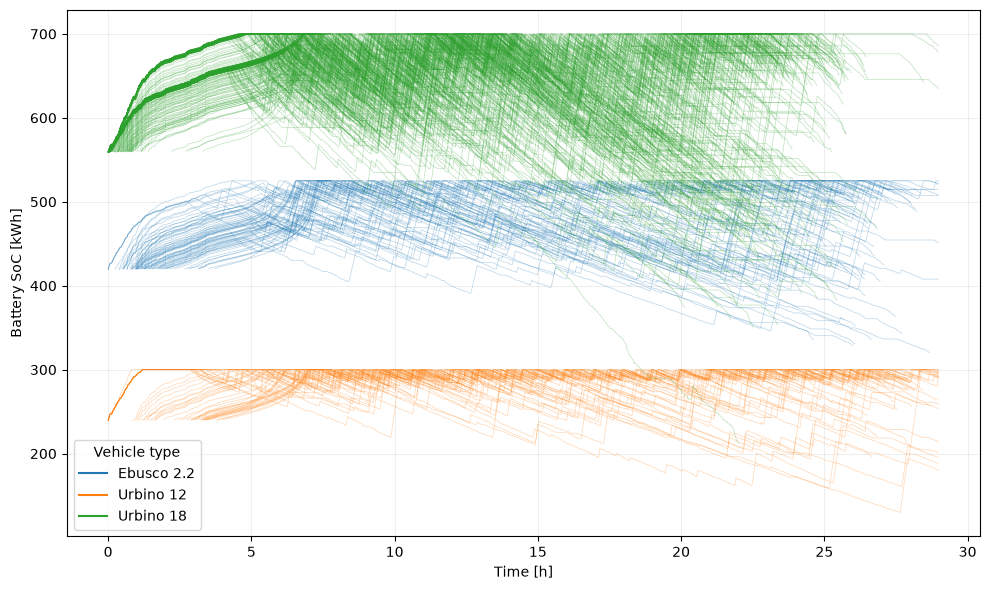

In [19]:
def battery_soc_over_time():
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute("""
        SELECT
            bat.timestep_time,
            bat.vehicle_actualBatteryCapacity,
            bat.vehicle_id,
            trip.tripinfo_vType,
            bat.scenario,
            bat.seed
        FROM multirun_battery_aggregated AS bat
        JOIN multirun_tripinfo AS trip
            ON trip.tripinfo_id = bat.vehicle_id
        WHERE bat.seed = 65
        AND trip.seed = 65
        ORDER BY bat.timestep_time, bat.vehicle_id
    """).fetchdf()
    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["vehicle_actualBatteryCapacity"] = df["vehicle_actualBatteryCapacity"] / 1000

    print(df.head())

    for scenario in ["summer", "winter", "reduced", "increased"]:
        fig, ax = plt.subplots(figsize=(10, 6))

        subset = df[df["scenario"] == scenario]

        vtypes = sorted(subset["tripinfo_vType"].unique())
        colors = plt.cm.tab10(range(len(vtypes)))
        color_map = dict(zip(vtypes, colors))

        for vehicle_id, vehicle_subset in subset.groupby("vehicle_id"):
            vehicle_type = vehicle_subset["tripinfo_vType"].iloc[0]
            vehicle_subset = vehicle_subset.sort_values("timestep_time")

            ax.plot(
                vehicle_subset["timestep_time"],
                vehicle_subset["vehicle_actualBatteryCapacity"],
                color=color_map[vehicle_type],
                alpha=0.3,
                linewidth=0.5,
            )

        # Create legend entries for vehicle types
        for vtype in vtypes:
            ax.plot(
                [],
                [],
                color=color_map[vtype],
                label=VEHICLE_DICT.get(vtype),
                linewidth=1.5,
            )

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Battery SoC [kWh]")
        ax.legend(title="Vehicle type")
        ax.grid(True, alpha=0.2)

        fig.tight_layout()
        fig.savefig(
            os.path.join(OUTPUT_PATH, f"{scenario}_battery_soc_over_time.pdf")
        )
        print(scenario)
        plt.show()
        plt.close(fig)
battery_soc_over_time()

### Energy Efficiency over average Speed

count    1556.000000
mean        8.881560
std         1.626586
min         6.012222
25%         7.662778
50%         8.365000
75%        10.048333
max        13.690833
Name: driving_time, dtype: float64
count      1556.000000
mean      86473.758355
std        6192.120808
min       70016.000000
25%       82238.000000
50%       87372.000000
75%       90583.000000
max      102419.000000
Name: tripinfo_duration, dtype: float64
count     1556.000000
mean      4460.593830
std       1656.551369
min       1188.000000
25%       3350.000000
50%       4226.000000
75%       5346.000000
max      12924.000000
Name: tripinfo_waitingTime, dtype: float64
count     1556.000000
mean     50039.547558
std       4814.757034
min      31705.000000
25%      47052.000000
50%      50266.000000
75%      53315.000000
max      62205.000000
Name: tripinfo_stopTime, dtype: float64
summer


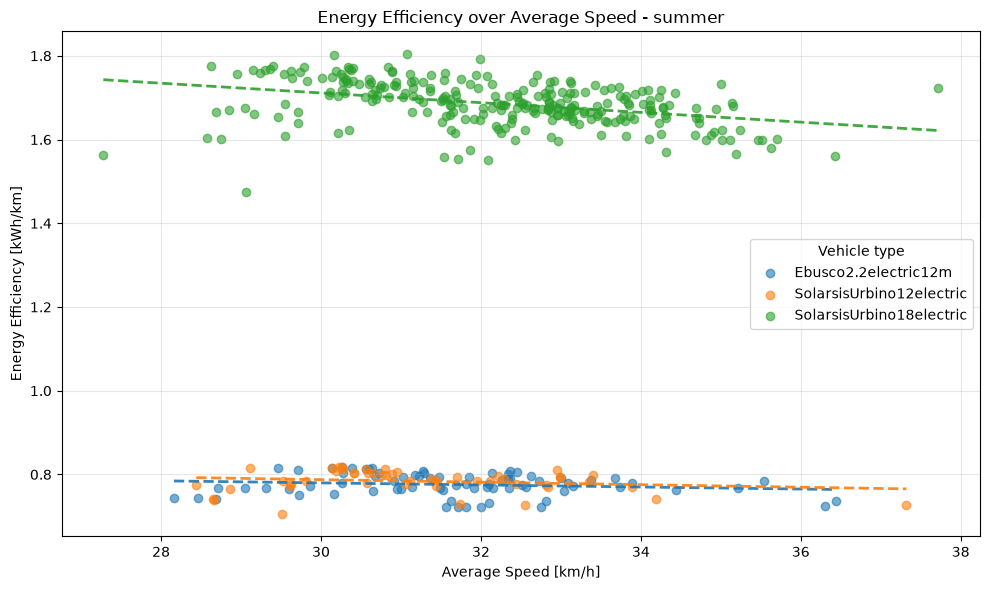

winter


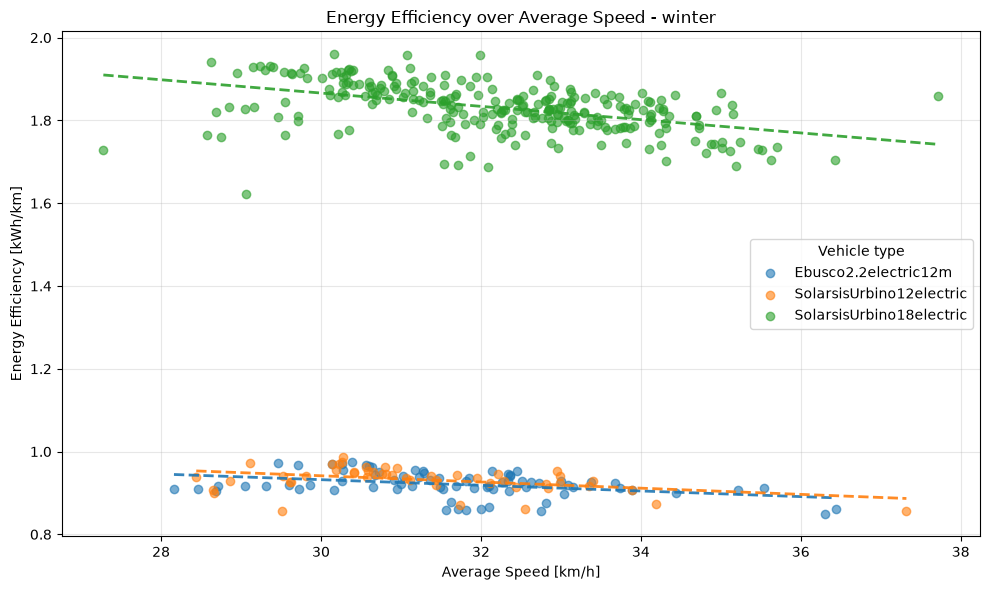

reduced


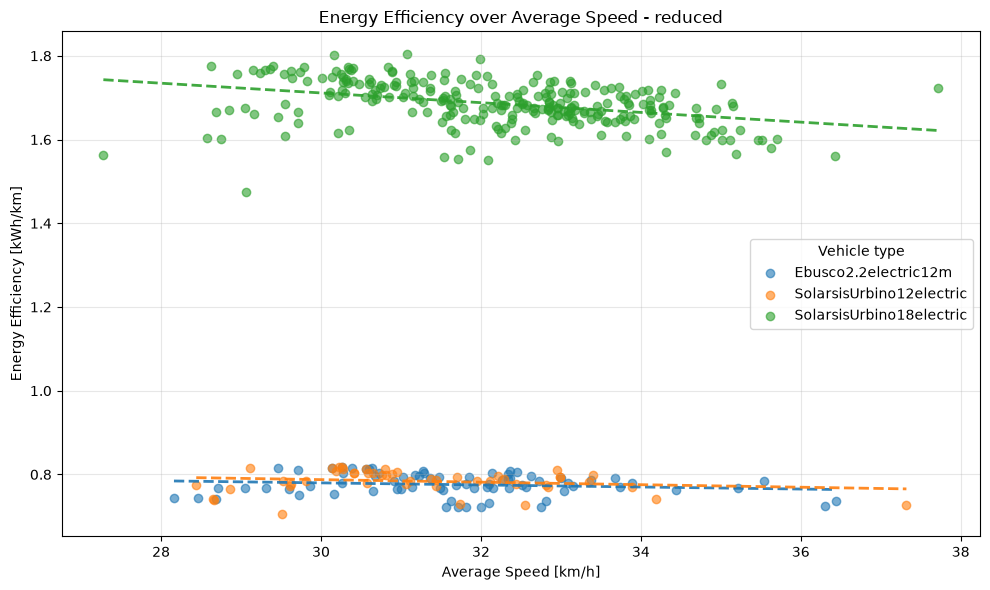

increased


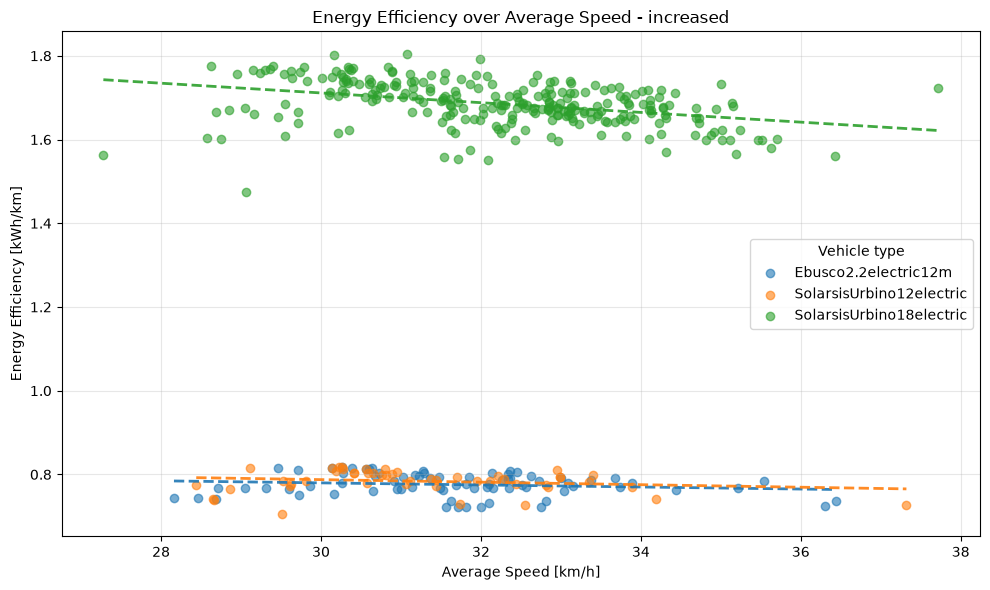

In [8]:
def energy_efficiency_over_avg_speed():
        con = duckdb.connect(DATABASE_PATH)
        df = con.execute("""
            SELECT
                battery_totalEnergyConsumed,
                battery_totalEnergyRegenerated,
                tripinfo_arrival,
                tripinfo_waitingTime,
                tripinfo_depart,
                tripinfo_stopTime,
                tripinfo_routeLength,
                tripinfo_vType,
                tripinfo_duration,
                scenario,
                seed
            FROM multirun_tripinfo
            WHERE seed = 65
        """).fetchdf()
        con.close()


        df["battery_totalEnergyConsumed"] = df["battery_totalEnergyConsumed"] / 1_000
        df["tripinfo_routeLength"] = df["tripinfo_routeLength"] / 1_000
        df["battery_totalEnergyRegenerated"] = df["battery_totalEnergyRegenerated"] / 1000
        df["efficiency"] = (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"]) / df["tripinfo_routeLength"]

        df["driving_time"] = (
            df["tripinfo_duration"]
            - df["tripinfo_waitingTime"] 
            - df["tripinfo_stopTime"]
            ) / 3600

        print(df["driving_time"].describe())
        print(df["tripinfo_duration"].describe())
        print(df["tripinfo_waitingTime"].describe())
        print(df["tripinfo_stopTime"].describe())
        
        df["average_speed"] = df["tripinfo_routeLength"] / df["driving_time"]

        for scenario in ["summer", "winter", "reduced", "increased"]:
            subset = df[df["scenario"] == scenario]

            print(scenario)

            fig, ax = plt.subplots(figsize=(10, 6))

            vtypes = sorted(subset["tripinfo_vType"].unique())

            for vtype in vtypes:
                vtype_subset = subset[subset["tripinfo_vType"] == vtype].dropna(
                    subset=["average_speed", "efficiency"]
                )

                scatter = ax.scatter(
                    vtype_subset["average_speed"],
                    vtype_subset["efficiency"],
                    label=vtype,
                    alpha=0.6
                )
                color = scatter.get_facecolor()[0]

                # Linear trend line
                x = vtype_subset["average_speed"].to_numpy()
                y = vtype_subset["efficiency"].to_numpy()

                if len(x) >= 2:
                    slope, intercept = np.polyfit(x, y, 1)

                    x_trend = np.linspace(x.min(), x.max(), 100)
                    y_trend = slope * x_trend + intercept

                    ax.plot(
                        x_trend,
                        y_trend,
                        color=color,
                        linestyle="--",
                        alpha=0.9,
                        linewidth=2
                    )

            ax.set_xlabel("Average Speed [km/h]")
            ax.set_ylabel("Energy Efficiency [kWh/km]")
            ax.set_title(f"Energy Efficiency over Average Speed - {scenario}")
            ax.legend(title="Vehicle type")
            ax.grid(True, alpha=0.3)

            fig.tight_layout()
            fig.savefig(
                os.path.join(OUTPUT_PATH, f"{scenario}_efficiency_over_speed.pdf")
            )

            plt.show()
            plt.close(fig)

energy_efficiency_over_avg_speed()

### Energy Efficiency over average Speed Stop Correllation